In [1]:
import openmc
import openmc.model
import numpy as np
import matplotlib.pyplot as plt
import os
import math

def generate_ipwr_assembly(
    lattice_type="Square",         # "Square" veya "Hexagonal"
    active_height=200.0,           # Z-Ekseni aktif uzunluğu (cm)
    pin_pitch=1.25984,             # Çubuklar arası adım (cm)
    fuel_radius=0.39218,           # Yakıt pelet yarıçapı (cm)
    gap_radius=0.40005,            # Helyum boşluğu dış yarıçapı (cm)
    clad_radius=0.45720,           # Kılıf dış yarıçapı (cm)
    gt_inner_radius=0.56134,       # Kılavuz tüp iç yarıçapı (cm)
    gt_outer_radius=0.60198,       # Kılavuz tüp dış yarıçapı (cm)
    enrichment=0.045,              # U-235 zenginlik oranı (0.02 - 0.05)
    fuel_material="UO2",           # "UO2" veya "UO2-Gd2O3" (Zehirli)
    poison_fraction=0.02,          # Eğer zehirliyse Gd2O3 kütlesel oranı
    clad_material="Zircaloy4",     # "Zircaloy4", "M5" veya "Q12"
    boron_ppm=975.0,               # Soğutucudaki bor miktarı (PPM)
    control_rods_inserted=False,   # Kontrol çubukları içeride mi? (
    particles=10000,               # Simülasyon parçacık sayısı
    batches=60                     # Simülasyon jenerasyon sayısı
):
    print(f" GENERIC iPWR ENGINE: {lattice_type} | Yakıt: {fuel_material} | Kılıf: {clad_material}")
    print(f" Geometri: Aktif Boy={active_height}cm | Bor={boron_ppm}ppm | Çubuklar={control_rods_inserted}")

    # malzeme tanımlama 
    materials_list = []

    # Standart UO2 Yakıtı
    yakit = openmc.Material(name='iPWR_Standard_UO2')
    yakit.set_density('g/cm3', 10.42)
    m_u = enrichment * 235.04 + (1.0 - enrichment) * 238.05
    m_o2 = 2 * 15.995
    m_uo2 = m_u + m_o2
    yakit.add_nuclide('U235', enrichment * (m_u / m_uo2), 'wo')
    yakit.add_nuclide('U238', (1.0 - enrichment) * (m_u / m_uo2), 'wo')
    yakit.add_nuclide('O16', m_o2 / m_uo2, 'wo')
    materials_list.append(yakit)

    # Gadolinyum Zehirli Yakıt (Opsiyonel)
    if fuel_material == "UO2-Gd2O3":
        zehirli_yakit = openmc.Material(name='iPWR_Poisoned_UO2')
        zehirli_yakit.set_density('g/cm3', 10.20)
        zehirli_yakit.add_nuclide('U235', (enrichment * (m_u / m_uo2)) * (1.0 - poison_fraction), 'wo')
        zehirli_yakit.add_nuclide('U238', ((1.0 - enrichment) * (m_u / m_uo2)) * (1.0 - poison_fraction), 'wo')
        zehirli_yakit.add_nuclide('O16', (m_o2 / m_uo2) * (1.0 - poison_fraction), 'wo')
        zehirli_yakit.add_element('Gd', poison_fraction, 'wo')
        materials_list.append(zehirli_yakit)

    # kılıf Malzemesi Seçimi
    kilif = openmc.Material(name=f'iPWR_Clad_{clad_material}')
    if clad_material == "Zircaloy4":
        kilif.set_density('g/cm3', 6.56)
        kilif.add_element('Zr', 0.9823, 'wo')
        kilif.add_element('Sn', 0.0145, 'wo')
        kilif.add_element('Fe', 0.0021, 'wo')
        kilif.add_element('Cr', 0.0011, 'wo')
    elif clad_material in ["M5", "Q12"]:
        kilif.set_density('g/cm3', 6.55)
        kilif.add_element('Zr', 0.9885, 'wo')
        kilif.add_element('Nb', 0.0100, 'wo')
        kilif.add_nuclide('O16', 0.0015, 'wo')
    materials_list.append(kilif)

    # Helyum Gaz Boşluğu
    helium = openmc.Material(name='iPWR_Gap_Helium')
    helium.set_density('g/cm3', 0.001598)
    helium.add_element('He', 1.0)
    materials_list.append(helium)

    # HARMONI Kontrol Çubuğu Yutucusu (AIC Alaşımı)
    aic = openmc.Material(name='iPWR_AIC_Absorber')
    aic.set_density('g/cm3', 10.17)
    aic.add_element('Ag', 0.80, 'wo')
    aic.add_element('In', 0.15, 'wo')
    aic.add_element('Cd', 0.05, 'wo')
    materials_list.append(aic)

    # Kontrol Çubuğu SS304 Kılıfı
    ss304 = openmc.Material(name='iPWR_SS304')
    ss304.set_density('g/cm3', 8.00)
    ss304.add_element('Fe', 0.68, 'wo')
    ss304.add_element('Cr', 0.19, 'wo')
    ss304.add_element('Ni', 0.10, 'wo')
    materials_list.append(ss304)

    # Borlu Su Soğutucu
    su = openmc.Material(name='iPWR_Coolant_Water')
    su.set_density('g/cm3', 0.740582)
    su.temperature = 566.5
    boron_wt = boron_ppm * 1e-6
    water_wt = 1.0 - boron_wt
    m_H2O = 2 * 1.008 + 15.995
    su.add_element('H', water_wt * (2 * 1.008) / m_H2O, 'wo')
    su.add_nuclide('O16', water_wt * 15.995 / m_H2O, 'wo')
    su.add_element('B', boron_wt, 'wo')
    materials_list.append(su)

    materials = openmc.Materials(materials_list)
    materials.export_to_xml()

    # geometri
    r_fuel = openmc.ZCylinder(r=fuel_radius)
    r_gap  = openmc.ZCylinder(r=gap_radius)
    r_clad = openmc.ZCylinder(r=clad_radius)
    r_gt_in = openmc.ZCylinder(r=gt_inner_radius)
    r_gt_out = openmc.ZCylinder(r=gt_outer_radius)
    
    # Kontrol Çubuğu Radyal Ayarı
    r_aic = openmc.ZCylinder(r=gt_inner_radius * 0.78)
    r_aic_gap = openmc.ZCylinder(r=gt_inner_radius * 0.80)
    r_aic_clad = openmc.ZCylinder(r=gt_inner_radius * 0.88)

    #  Standart Yakıt Evren (F)
    f_c1 = openmc.Cell(fill=yakit, region=-r_fuel)
    f_c2 = openmc.Cell(fill=helium, region=+r_fuel & -r_gap)
    f_c3 = openmc.Cell(fill=kilif, region=+r_gap & -r_clad)
    f_c4 = openmc.Cell(fill=su, region=+r_clad)
    F = openmc.Universe(cells=[f_c1, f_c2, f_c3, f_c4])

    #  Zehirli Yakıt Evren (P)
    if fuel_material == "UO2-Gd2O3":
        p_c1 = openmc.Cell(fill=zehirli_yakit, region=-r_fuel)
        p_c2 = openmc.Cell(fill=helium, region=+r_fuel & -r_gap)
        p_c3 = openmc.Cell(fill=kilif, region=+r_gap & -r_clad)
        p_c4 = openmc.Cell(fill=su, region=+r_clad)
        P = openmc.Universe(cells=[p_c1, p_c2, p_c3, p_c4])
    else:
        P = F 

    #  Boş Kılavuz Tüp Evren (G)
    g_c1 = openmc.Cell(fill=su, region=-r_gt_in)
    g_c2 = openmc.Cell(fill=kilif, region=+r_gt_in & -r_gt_out)
    g_c3 = openmc.Cell(fill=su, region=+r_gt_out)
    G = openmc.Universe(cells=[g_c1, g_c2, g_c3])

    #  Dolu Kılavuz Tüp Evren (C) (Kontrol Çubuğu İçeride)
    c_c1 = openmc.Cell(fill=aic, region=-r_aic)
    c_c2 = openmc.Cell(fill=helium, region=+r_aic & -r_aic_gap)
    c_c3 = openmc.Cell(fill=ss304, region=+r_aic_gap & -r_aic_clad)
    c_c4 = openmc.Cell(fill=su, region=+r_aic_clad & -r_gt_in)
    c_c5 = openmc.Cell(fill=kilif, region=+r_gt_in & -r_gt_out)
    c_c6 = openmc.Cell(fill=su, region=+r_gt_out)
    C = openmc.Universe(cells=[c_c1, c_c2, c_c3, c_c4, c_c5, c_c6])

    X = C if control_rods_inserted else G

    # 3. LATTICE VE DIŞ SINIR MOTORU (KARE / ALTIGEN SEÇİMİ)
    z_half = active_height / 2.0
    
    if lattice_type == "Square":
        offset = (17 * pin_pitch) / 2.0
        lattice = openmc.RectLattice()
        lattice.pitch = (pin_pitch, pin_pitch)
        lattice.lower_left = (-offset, -offset)
        
        # mPower tarzı simetrik zehir/kontrol matrisi dağılımı
        lattice.universes = [
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
            [F, P, F, P, F, F, P, F, F, F, P, F, F, P, F, P, F],
            [F, F, F, F, F, X, F, F, X, F, F, X, F, F, F, F, F],
            [F, P, F, X, F, F, F, F, F, F, F, F, F, X, F, P, F],
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
            [F, F, X, F, F, X, F, F, X, F, F, X, F, F, X, F, F],
            [F, P, F, F, F, F, F, F, F, F, F, F, F, F, F, P, F],
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
            [F, F, X, F, F, X, F, F, G, F, F, X, F, F, X, F, F],
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
            [F, P, F, F, F, F, F, F, F, F, F, F, F, F, F, P, F],
            [F, F, X, F, F, X, F, F, X, F, F, X, F, F, X, F, F],
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
            [F, P, F, X, F, F, F, F, F, F, F, F, F, X, F, P, F],
            [F, F, F, F, F, X, F, F, X, F, F, X, F, F, F, F, F],
            [F, P, F, P, F, F, P, F, F, F, P, F, F, P, F, P, F],
            [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F]
        ]
        lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=su)])
        
        min_x = openmc.XPlane(x0=-offset, boundary_type='reflective')
        max_x = openmc.XPlane(x0=offset, boundary_type='reflective')
        min_y = openmc.YPlane(y0=-offset, boundary_type='reflective')
        max_y = openmc.YPlane(y0=offset, boundary_type='reflective')
        region_box = +min_x & -max_x & +min_y & -max_y

    elif lattice_type == "Hexagonal":
        # CAREM-25 Altıgen algoritması 
        offset = 6.5 * pin_pitch
        edge_len = (offset * 2) / math.sqrt(3)
        hex_prism = openmc.model.HexagonalPrism(orientation='y', edge_length=edge_len, boundary_type='reflective')
        region_box = -hex_prism
        
        lattice = openmc.HexLattice()
        lattice.center = (0.0, 0.0)
        lattice.pitch = [pin_pitch]
        lattice.universes = [[F]*36, [X,F,F,F,F]*6, [X,F,F,F]*6, [X,F,F]*6, [F]*12, [F]*6, [G]]
        lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=su)])

    # Evrensel Z Sınırları
    min_z = openmc.ZPlane(z0=-z_half, boundary_type='reflective')
    max_z = openmc.ZPlane(z0=z_half, boundary_type='reflective')
    
    final_region = region_box & +min_z & -max_z
    main_cell = openmc.Cell(fill=lattice, region=final_region)
    geometry = openmc.Geometry([main_cell])
    geometry.export_to_xml()

    # TALLIES
    settings = openmc.Settings()
    settings.batches = batches
    settings.inactive = max(10, int(batches * 0.2))
    settings.particles = particles
    settings.temperature = {'method': 'interpolation'}
    
    spatial_dist = openmc.stats.Box((-offset, -offset, -z_half), (offset, offset, z_half))
    settings.source = openmc.IndependentSource(space=spatial_dist, constraints={'fissionable': True})
    settings.export_to_xml()

    mesh = openmc.RegularMesh()
    mesh.dimension = [170, 170]
    mesh.lower_left = [-offset*1.05, -offset*1.05]
    mesh.upper_right = [offset*1.05, offset*1.05]
    
    super_tally = openmc.Tally(name='iPWR_Super_Tally')
    super_tally.filters = [openmc.MeshFilter(mesh)]
    super_tally.scores = ['flux', 'fission', 'absorption']
    
    tallies = openmc.Tallies([super_tally])
    tallies.export_to_xml()

    print("Evrensel XML Girişleri Kaydedildi.")
    return offset

In [2]:
mesh_offset = generate_ipwr_assembly(
    lattice_type="Square",          # Matris Tipi
    active_height=241.3,            # mPower aktif yüksekliği
    enrichment=0.0495,              # Zenginlik oranı %4.95
    fuel_material="UO2-Gd2O3",      # Yanabilir zehir aktif
    poison_fraction=0.03,           # %3 Gadolinyum katkısı
    clad_material="M5",             # Gelişmiş kılıf seçimi
    boron_ppm=0.0,                  # Borsuz işletme modu (SBF)
    control_rods_inserted=True,     # Kontrol çubukları reaktörü frenliyor
    particles=10000,                # İdeal hassasiyet
    batches=50                      # Jenerasyon sayısı
)

openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
print("\n Evrensel iPWR simülasyonu başlıyor ")
openmc.run()

 GENERIC iPWR ENGINE: Square | Yakıt: UO2-Gd2O3 | Kılıf: M5
 Geometri: Aktif Boy=241.3cm | Bor=0.0ppm | Çubuklar=True
Evrensel XML Girişleri Kaydedildi.

 Evrensel iPWR simülasyonu başlıyor 
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                #####################

k_eff : Bir reaktördeki nötronların nesilden nesile ne kadar çoğaldığını gösterir. Gerçek bir reaktörde nötronların bir kısmı dışarı kaçar (Sızıntı/Leakage). Eğer k_eff= 1.0 ise reaktör kararlı çalışıyor demektir. 1.0'ın altı sönümlenmeyi, üstü ise patlamaya/erimeye giden kontrolsüz güç artışını ifade eder. 

Kritiklik Analizi (Combined $k_{eff} = 0.89623 \pm 0.00170$)


Evrensel HDF5 Dosyasından Veriler Çekiliyor...
Okunan Dosya: statepoint.50.h5


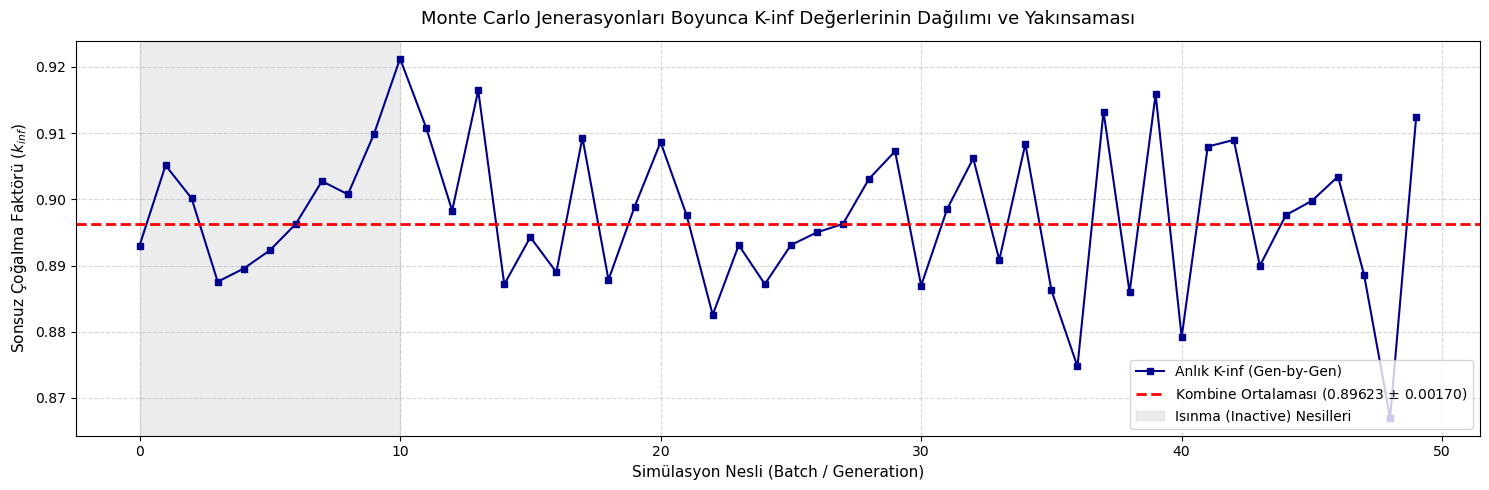

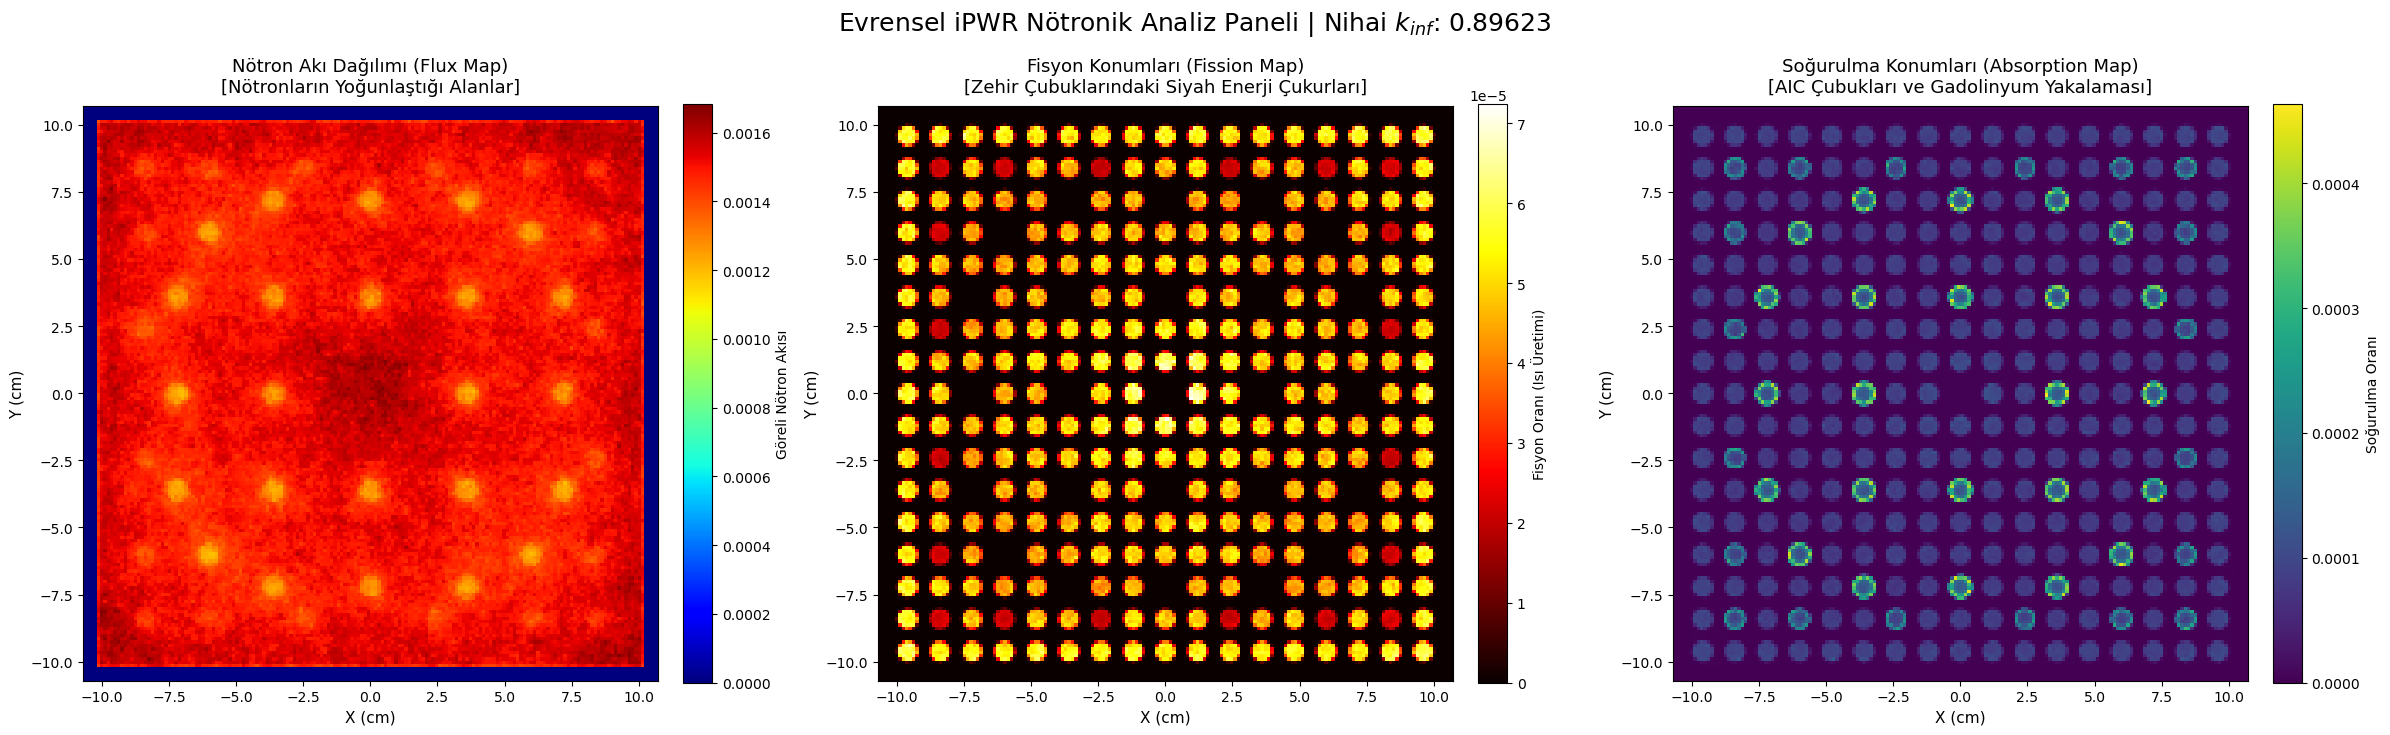


Tüm nötronik grafik analizleri tamamlandı


In [3]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("\nEvrensel HDF5 Dosyasından Veriler Çekiliyor...")

statepoint_files = glob.glob('statepoint.*.h5')

latest_sp = max(statepoint_files, key=os.path.getctime)
print(f"Okunan Dosya: {latest_sp}")

with openmc.StatePoint(latest_sp) as sp:
    k_generation = sp.k_generation
    k_combined = sp.keff
    
    tally = sp.get_tally(name='iPWR_Super_Tally')
    
    flux_matrix = tally.get_slice(scores=['flux']).mean.reshape((170, 170))
    fission_matrix = tally.get_slice(scores=['fission']).mean.reshape((170, 170))
    absorption_matrix = tally.get_slice(scores=['absorption']).mean.reshape((170, 170))

flux_matrix = np.flipud(flux_matrix)
fission_matrix = np.flipud(fission_matrix)
absorption_matrix = np.flipud(absorption_matrix)

try:
    ext = [-mesh_offset, mesh_offset, -mesh_offset, mesh_offset]
except NameError:
    backup_offset = (17 * 1.25984) / 2.0
    ext = [-backup_offset, backup_offset, -backup_offset, backup_offset]

# K-INF DEĞERLERİNİN DAĞILIMI (K-inf Convergence)
plt.figure(figsize=(15, 5))
plt.plot(k_generation, marker='s', color='darkblue', linestyle='-', linewidth=1.5, markersize=4, label='Anlık K-inf (Gen-by-Gen)')
plt.axhline(k_combined.nominal_value, color='red', linestyle='--', linewidth=2, 
            label=f'Kombine Ortalaması ({k_combined.nominal_value:.5f} $\pm$ {k_combined.std_dev:.5f})')

inactive_cutoff = int(len(k_generation) * 0.2)
plt.axvspan(0, inactive_cutoff, color='gray', alpha=0.15, label='Isınma (Inactive) Nesilleri')

plt.title('Monte Carlo Jenerasyonları Boyunca K-inf Değerlerinin Dağılımı ve Yakınsaması', fontsize=13, pad=12)
plt.xlabel('Simülasyon Nesli (Batch / Generation)', fontsize=11)
plt.ylabel('Sonsuz Çoğalma Faktörü ($k_{inf}$)', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

#  2D REAKTÖR ISI VE REAKSİYON HARİTALARI (3'lü Panel)
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
fig.suptitle(f'Evrensel iPWR Nötronik Analiz Paneli | Nihai $k_{{inf}}$: {k_combined.nominal_value:.5f}', fontsize=18, y=0.98)

#  Nötron Akısı (Flux Map)
im0 = axes[0].imshow(flux_matrix, interpolation='nearest', cmap='jet', extent=ext)
axes[0].set_title('Nötron Akı Dağılımı (Flux Map)\n[Nötronların Yoğunlaştığı Alanlar]', fontsize=13, pad=10)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Göreli Nötron Akısı')

#  Fisyon Konumları (Fission Density)
im1 = axes[1].imshow(fission_matrix, interpolation='nearest', cmap='hot', extent=ext)
axes[1].set_title('Fisyon Konumları (Fission Map)\n[Zehir Çubuklarındaki Siyah Enerji Çukurları]', fontsize=13, pad=10)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Fisyon Oranı (Isı Üretimi)')

# Soğurulma (Absorption) Konumları
im2 = axes[2].imshow(absorption_matrix, interpolation='nearest', cmap='viridis', extent=ext)
axes[2].set_title('Soğurulma Konumları (Absorption Map)\n[AIC Çubukları ve Gadolinyum Yakalaması]', fontsize=13, pad=10)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Soğurulma Oranı')

for ax in axes:
    ax.set_xlabel('X (cm)', fontsize=11)
    ax.set_ylabel('Y (cm)', fontsize=11)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

print("\nTüm nötronik grafik analizleri tamamlandı")

Sensörler (Tallies) güncelleniyor...

--- OPENMC SİMÜLASYONU BAŞLIYOR ---


Veriler işleniyor...


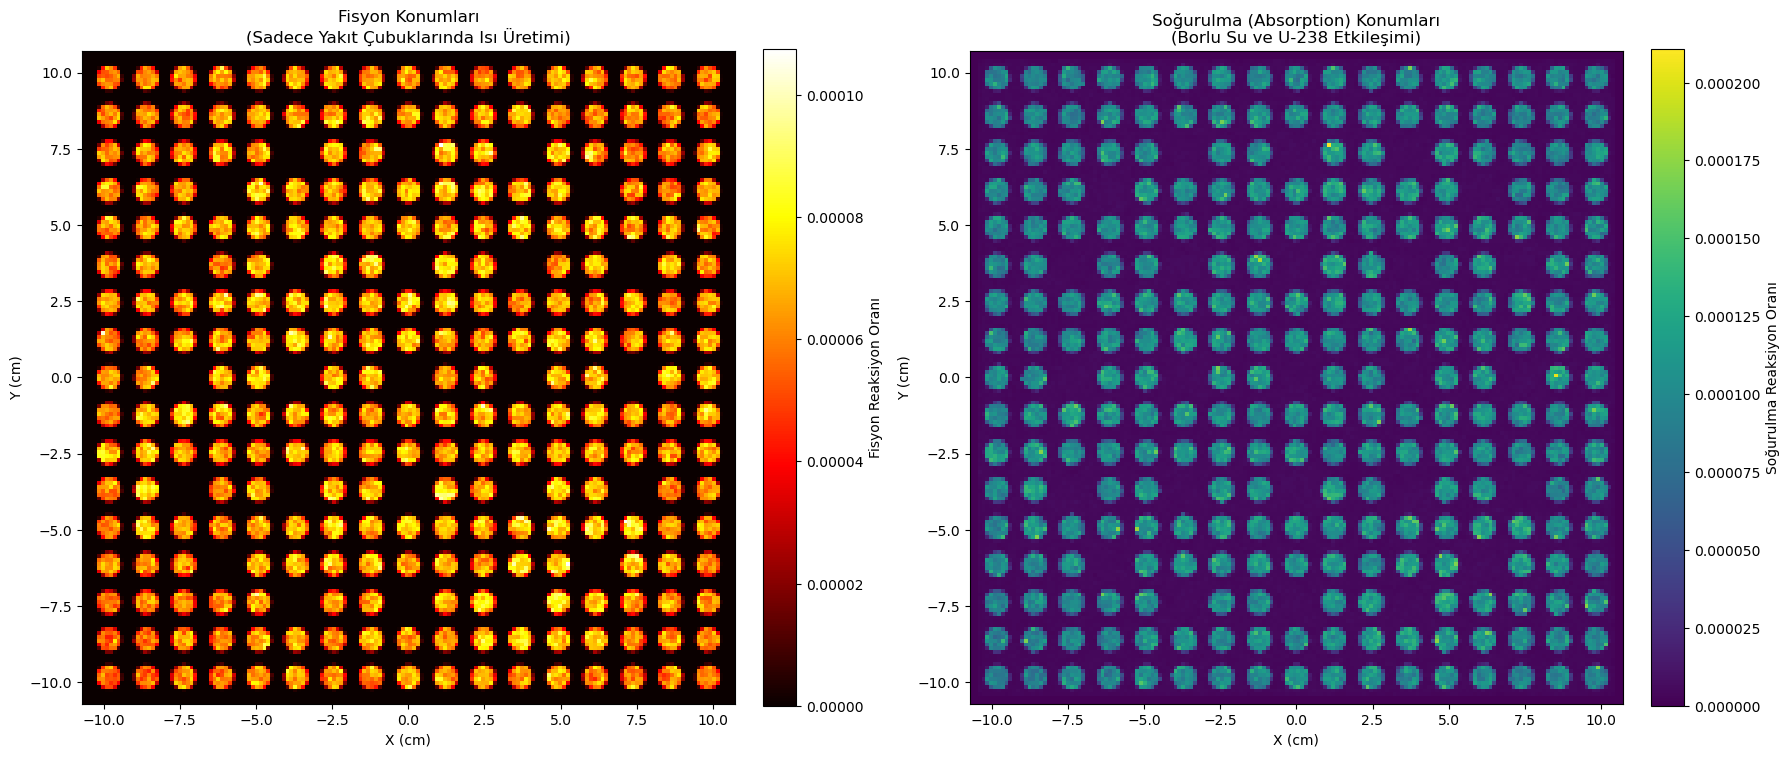

In [3]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("Sensörler (Tallies) güncelleniyor...")

offset = (17 * 1.25984) / 2.0
mesh = openmc.RegularMesh()
mesh.dimension = [170, 170]
mesh.lower_left = [-offset, -offset]
mesh.upper_right = [offset, offset]

reaction_tally = openmc.Tally(name='Reaksiyon_Haritalari')
reaction_tally.filters = [openmc.MeshFilter(mesh)]

reaction_tally.scores = ['fission', 'absorption'] 

tallies = openmc.Tallies([reaction_tally])
tallies.export_to_xml()

print("\n OPENMC SİMÜLASYONU  \n")
openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
openmc.run(output=False) 

print("\nVeriler işleniyor.")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    tally = sp.get_tally(name='Reaksiyon_Haritalari')
    
    fission_tally = tally.get_slice(scores=['fission'])
    absorption_tally = tally.get_slice(scores=['absorption'])
    
    fission_matrix = fission_tally.mean.reshape((170, 170))
    absorption_matrix = absorption_tally.mean.reshape((170, 170))

fission_matrix = np.flipud(fission_matrix)
absorption_matrix = np.flipud(absorption_matrix)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im1 = axes[0].imshow(fission_matrix, interpolation='nearest', cmap='hot', 
                     extent=[-offset, offset, -offset, offset])
axes[0].set_title('Fisyon Konumları\n(Sadece Yakıt Çubuklarında Isı Üretimi)')
axes[0].set_xlabel('X (cm)')
axes[0].set_ylabel('Y (cm)')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Fisyon Reaksiyon Oranı')

im2 = axes[1].imshow(absorption_matrix, interpolation='nearest', cmap='viridis', 
                     extent=[-offset, offset, -offset, offset])
axes[1].set_title('Soğurulma (Absorption) Konumları\n(Borlu Su ve U-238 Etkileşimi)')
axes[1].set_xlabel('X (cm)')
axes[1].set_ylabel('Y (cm)')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Soğurulma Reaksiyon Oranı')

plt.tight_layout()
plt.show()

In [4]:
import openmc
import numpy as np
import pandas as pd
import random
import time
import os

output_csv = "ipwr_dataset.csv"

columns = [
    "lattice_type", 
    "active_height_cm", 
    "pin_pitch_cm", 
    "fuel_radius_cm", 
    "clad_outer_radius_cm", 
    "u235_enrichment", 
    "fuel_material", 
    "boron_ppm", 
    "control_rods_inserted",
    "simulation_time_sec",
    "k_inf_std_dev",
    "k_inf" # 
]

pd.DataFrame(columns=columns).to_csv(output_csv, index=False)

print(f" Hedef: 50 Simülasyon\n")
print(f"Veriler '{output_csv}' dosyasına anlık olarak yazılıyor.\n")

start_time_all = time.time()

for i in range(1, 51):
    loop_start = time.time()
    
    lattice_choice = random.choice(["Square", "Hexagonal"])
    
    if lattice_choice == "Square":
        height_choice = random.choice([200.0, 241.3, 365.76])
        pitch_choice = 1.25984
        f_rad = 0.39218
        c_rad = 0.45720
        gt_in = 0.56134
        gt_out = 0.60198
    else:
        height_choice = 140.0
        pitch_choice = 1.38
        f_rad = 0.380
        c_rad = 0.450
        gt_in = 0.380
        gt_out = 0.450

    enrichment_choice = round(random.uniform(0.02, 0.05), 4) # %2 ile %5 arası zenginlik
    fuel_mat_choice = random.choice(["UO2", "UO2-Gd2O3"])
    boron_choice = round(random.uniform(0.0, 1500.0), 1) # 0 ile 1500 ppm arası bor
    rods_choice = random.choice([True, False]) 

    try:
        openmc.reset_auto_ids()
        
        # Parçacık sayısını 5000 yaptım
        mesh_offset = generate_ipwr_assembly(
            lattice_type=lattice_choice,
            active_height=height_choice,
            pin_pitch=pitch_choice,
            fuel_radius=f_rad,
            clad_radius=c_rad,
            gt_inner_radius=gt_in,
            gt_outer_radius=gt_out,
            enrichment=enrichment_choice,
            fuel_material=fuel_mat_choice,
            boron_ppm=boron_choice,
            control_rods_inserted=rods_choice,
            particles=5000, 
            batches=40      
        )
        
        openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
        openmc.run(output=False)
        
        statepoint_files = glob.glob('statepoint.*.h5')
        latest_sp = max(statepoint_files, key=os.path.getctime)
        
        with openmc.StatePoint(latest_sp) as sp:
            k_combined = sp.keff
            k_inf_val = k_combined.nominal_value
            k_inf_std = k_combined.std_dev
            
        os.remove(latest_sp)
        if os.path.exists(f"summary.h5"): os.remove(f"summary.h5")

    except Exception as e:
        print(f" Simülasyon {i} hata aldı, atlanıyor: {e}")
        continue
        
    loop_end = time.time()
    sim_duration = round(loop_end - loop_start, 2)
    
    row_data = {
        "lattice_type": lattice_choice,
        "active_height_cm": height_choice,
        "pin_pitch_cm": pitch_choice,
        "fuel_radius_cm": f_rad,
        "clad_outer_radius_cm": c_rad,
        "u235_enrichment": enrichment_choice,
        "fuel_material": fuel_mat_choice,
        "boron_ppm": boron_choice,
        "control_rods_inserted": int(rods_choice), 
        "simulation_time_sec": sim_duration,
        "k_inf_std_dev": k_inf_std,
        "k_inf": k_inf_val 
    }
    
    pd.DataFrame([row_data]).to_csv(output_csv, mode='a', header=False, index=False)
    
    print(f" [{i}/50] Tamamlandı | Süre: {sim_duration}sn | K_inf: {k_inf_val:.5f} | Tür: {lattice_choice}")

total_duration = round((time.time() - start_time_all) / 60.0, 2)
print(f"Toplam Harcanan Zaman: {total_duration} dakika.")

 Hedef: 50 Simülasyon

Veriler 'ipwr_dataset.csv' dosyasına anlık olarak yazılıyor.

 GENERIC iPWR ENGINE: Hexagonal | Yakıt: UO2-Gd2O3 | Kılıf: Zircaloy4
 Geometri: Aktif Boy=140.0cm | Bor=935.7ppm | Çubuklar=False
Evrensel XML Girişleri Kaydedildi.
 [1/50] Tamamlandı | Süre: 15.03sn | K_inf: 1.08803 | Tür: Hexagonal
 GENERIC iPWR ENGINE: Hexagonal | Yakıt: UO2-Gd2O3 | Kılıf: Zircaloy4
 Geometri: Aktif Boy=140.0cm | Bor=327.8ppm | Çubuklar=True
Evrensel XML Girişleri Kaydedildi.
 [2/50] Tamamlandı | Süre: 11.41sn | K_inf: 0.74745 | Tür: Hexagonal
 GENERIC iPWR ENGINE: Hexagonal | Yakıt: UO2-Gd2O3 | Kılıf: Zircaloy4
 Geometri: Aktif Boy=140.0cm | Bor=55.9ppm | Çubuklar=False
Evrensel XML Girişleri Kaydedildi.
 [3/50] Tamamlandı | Süre: 15.55sn | K_inf: 1.32100 | Tür: Hexagonal
 GENERIC iPWR ENGINE: Square | Yakıt: UO2 | Kılıf: Zircaloy4
 Geometri: Aktif Boy=241.3cm | Bor=851.1ppm | Çubuklar=False
Evrensel XML Girişleri Kaydedildi.
 [4/50] Tamamlandı | Süre: 10.07sn | K_inf: 1.29747 | T

VERİ SETİ GENEL BİLGİLERİ 
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lattice_type           50 non-null     str    
 1   active_height_cm       50 non-null     float64
 2   pin_pitch_cm           50 non-null     float64
 3   fuel_radius_cm         50 non-null     float64
 4   clad_outer_radius_cm   50 non-null     float64
 5   u235_enrichment        50 non-null     float64
 6   fuel_material          50 non-null     str    
 7   boron_ppm              50 non-null     float64
 8   control_rods_inserted  50 non-null     int64  
 9   simulation_time_sec    50 non-null     float64
 10  k_inf_std_dev          50 non-null     float64
 11  k_inf                  50 non-null     float64
dtypes: float64(9), int64(1), str(2)
memory usage: 4.8 KB
None

İSTATİSTİKSEL ÖZET 
       active_height_cm  pin_pitch_cm  fuel_radius_cm  clad_outer_rad

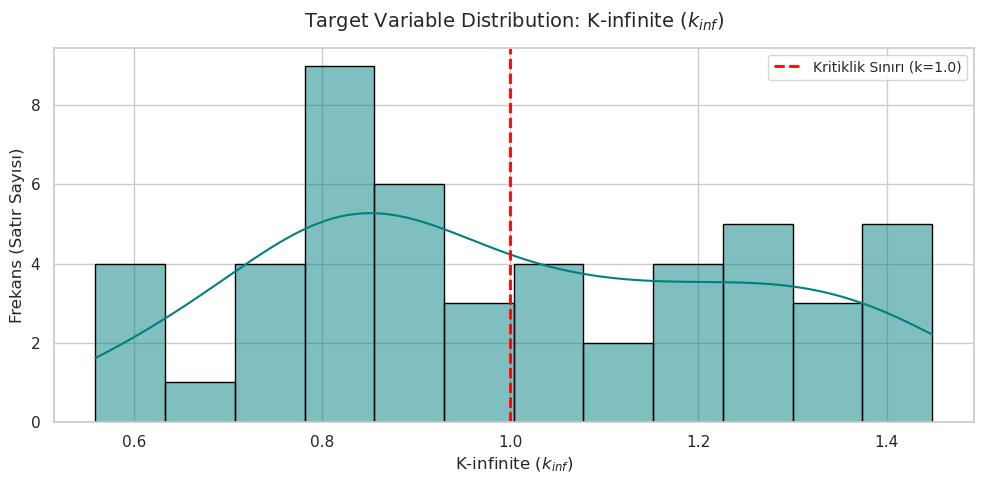

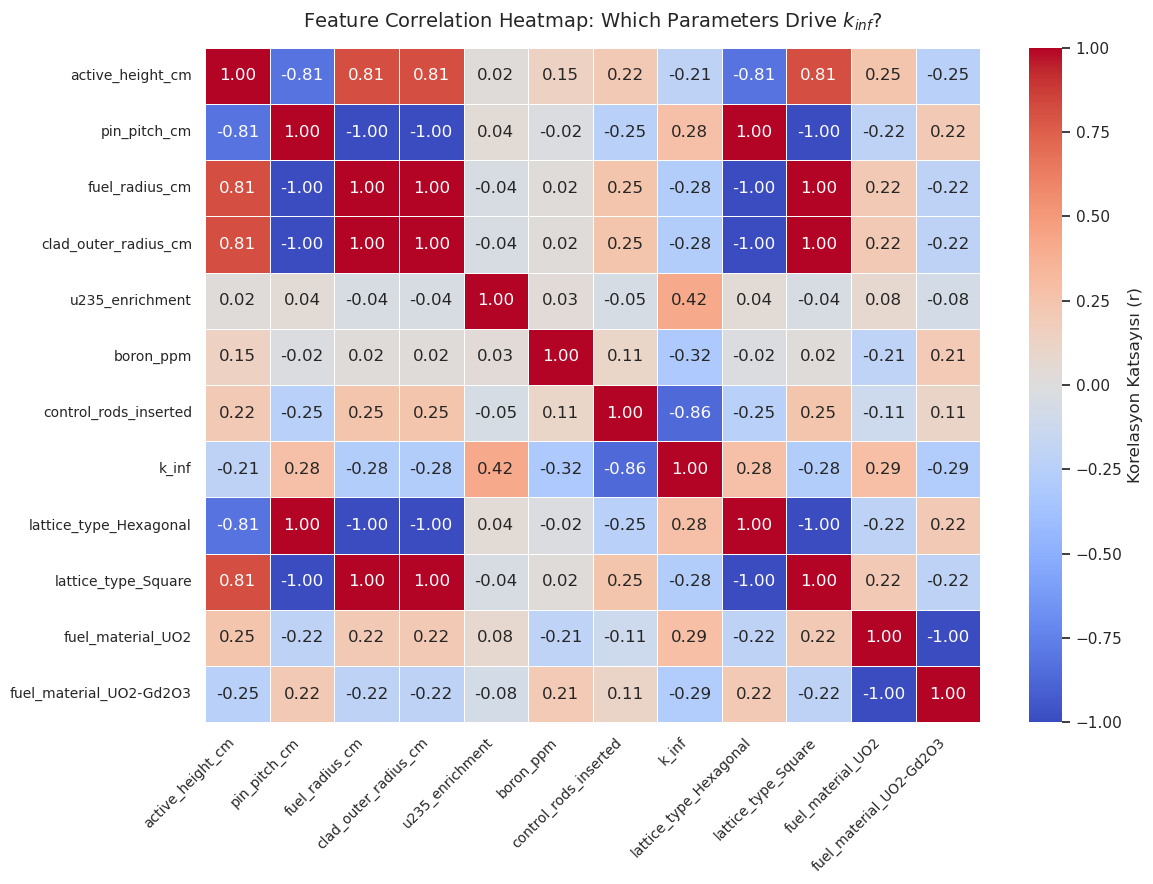

/tmp/ipykernel_751/567951159.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='control_rods_inserted', y='k_inf', ax=axes[0], palette='Set2')
/tmp/ipykernel_751/567951159.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fuel_material', y='k_inf', ax=axes[1], palette='Pastel1')


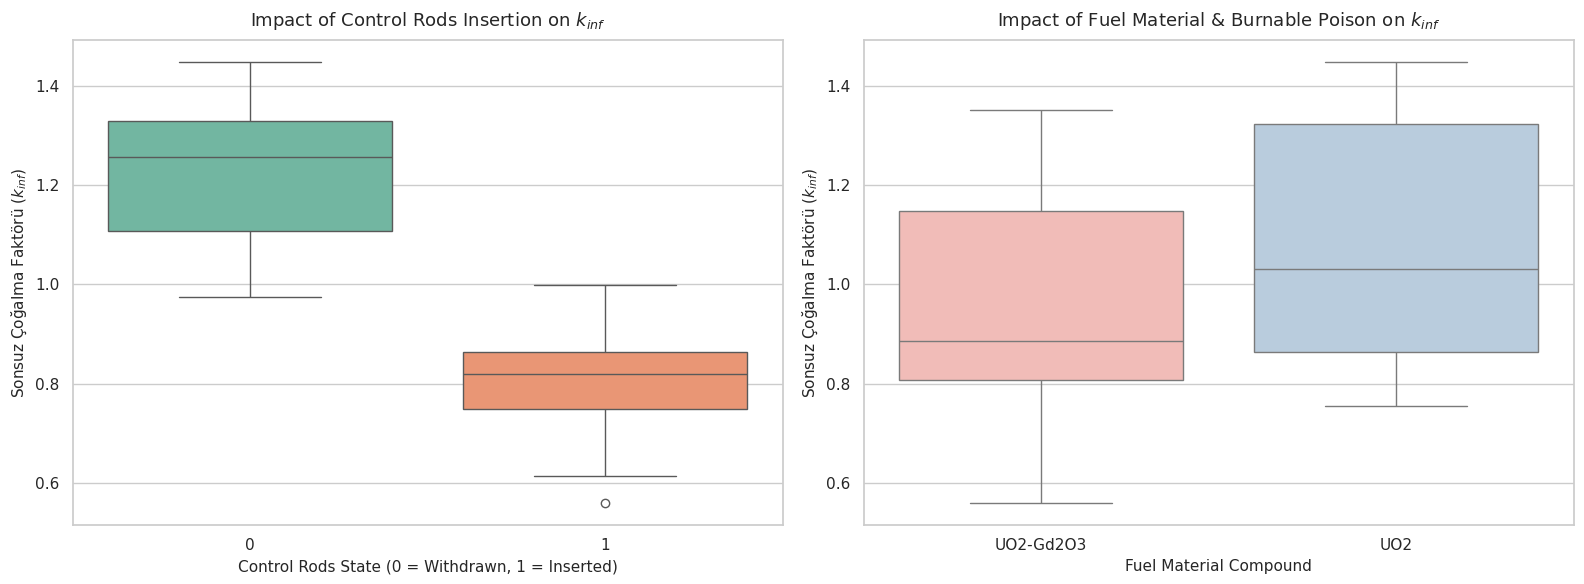

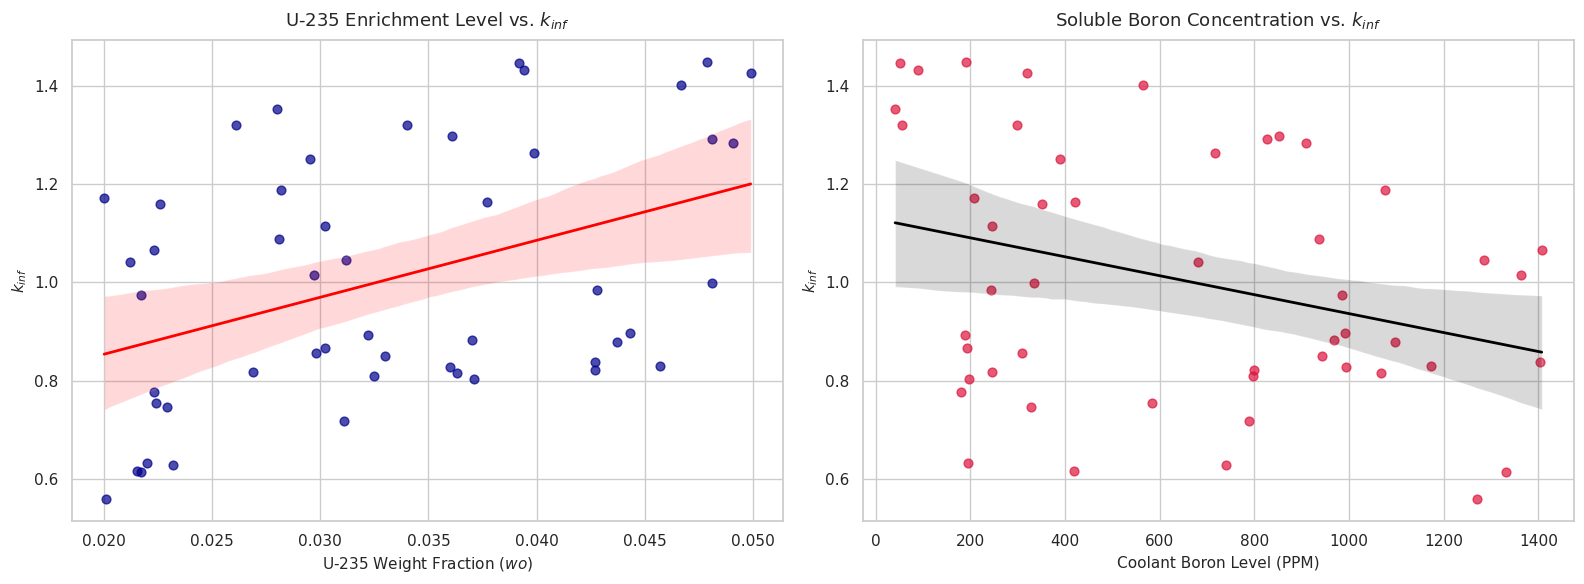

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ipwr_dataset.csv")

print("VERİ SETİ GENEL BİLGİLERİ ")
print(df.info())
print("\nİSTATİSTİKSEL ÖZET ")
print(df.describe())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['k_inf'], kde=True, color='teal', bins=12, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Kritiklik Sınırı (k=1.0)')
plt.title('Target Variable Distribution: K-infinite ($k_{inf}$)', fontsize=14, pad=15)
plt.xlabel('K-infinite ($k_{inf}$)', fontsize=12)
plt.ylabel('Frekans (Satır Sayısı)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

df_encoded = pd.get_dummies(df, columns=['lattice_type', 'fuel_material'], drop_first=False)

drop_cols = ['simulation_time_sec', 'k_inf_std_dev']
df_corr = df_encoded.drop(columns=[col for col in drop_cols if col in df_encoded.columns])

plt.figure(figsize=(12, 9))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, 
            cbar_kws={'label': 'Korelasyon Katsayısı (r)'})
plt.title('Feature Correlation Heatmap: Which Parameters Drive $k_{inf}$?', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='control_rods_inserted', y='k_inf', ax=axes[0], palette='Set2')
axes[0].set_title('Impact of Control Rods Insertion on $k_{inf}$', fontsize=13, pad=10)
axes[0].set_xlabel('Control Rods State (0 = Withdrawn, 1 = Inserted)', fontsize=11)
axes[0].set_ylabel('Sonsuz Çoğalma Faktörü ($k_{inf}$)', fontsize=11)

sns.boxplot(data=df, x='fuel_material', y='k_inf', ax=axes[1], palette='Pastel1')
axes[1].set_title('Impact of Fuel Material & Burnable Poison on $k_{inf}$', fontsize=13, pad=10)
axes[1].set_xlabel('Fuel Material Compound', fontsize=11)
axes[1].set_ylabel('Sonsuz Çoğalma Faktörü ($k_{inf}$)', fontsize=11)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='u235_enrichment', y='k_inf', ax=axes[0], color='darkblue', 
            scatter_kws={'alpha':0.7, 's':40}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('U-235 Enrichment Level vs. $k_{inf}$', fontsize=13, pad=10)
axes[0].set_xlabel('U-235 Weight Fraction ($wo$)', fontsize=11)
axes[0].set_ylabel('$k_{inf}$', fontsize=11)

sns.regplot(data=df, x='boron_ppm', y='k_inf', ax=axes[1], color='crimson', 
            scatter_kws={'alpha':0.7, 's':40}, line_kws={'color':'black', 'lw':2})
axes[1].set_title('Soluble Boron Concentration vs. $k_{inf}$', fontsize=13, pad=10)
axes[1].set_xlabel('Coolant Boron Level (PPM)', fontsize=11)
axes[1].set_ylabel('$k_{inf}$', fontsize=11)

plt.tight_layout()
plt.show()